## 1


==================== PART 1 ====================
Dimensions: (633, 800, 3)
Data Type: uint8
Channels: 3

==================== PART 2 ====================


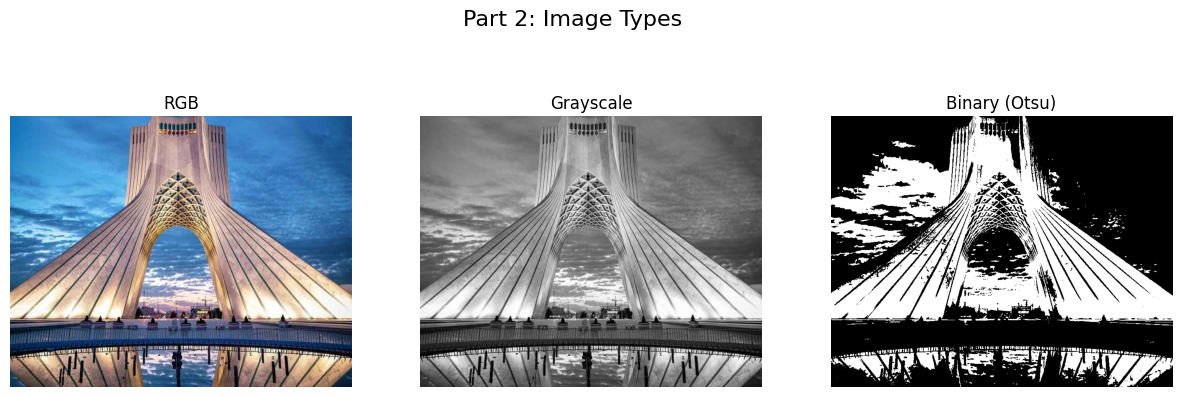


==================== PART 3 & 4 ====================


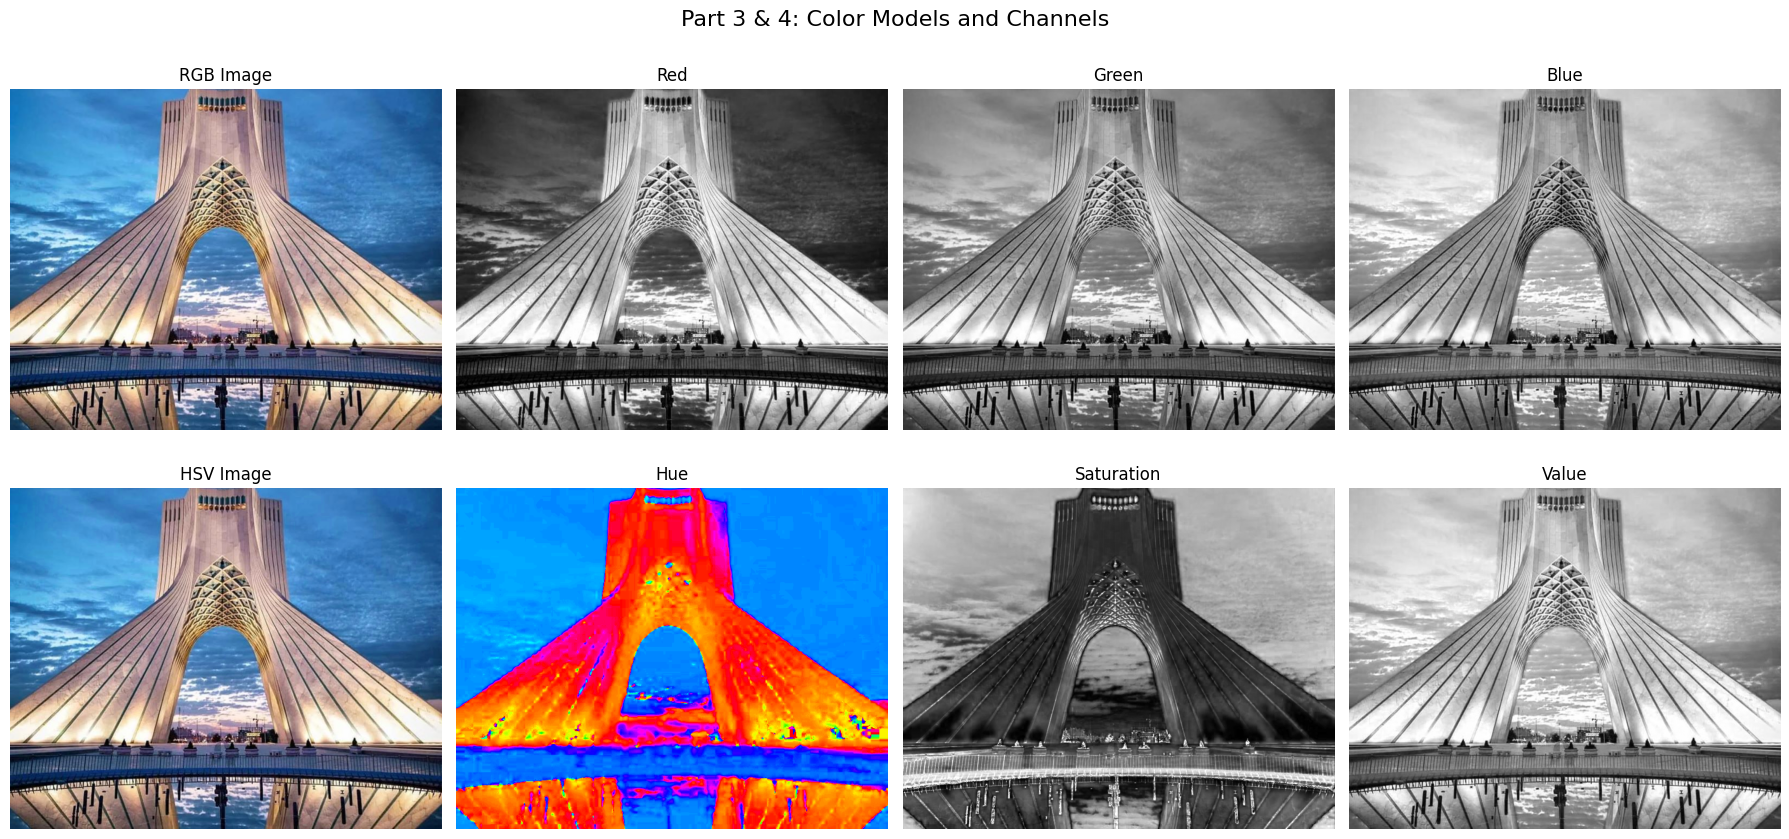


==================== PART 5 ====================
Base Contrast: 54.84
Contrast (Increased): 56.74
Contrast (Decreased): 21.94


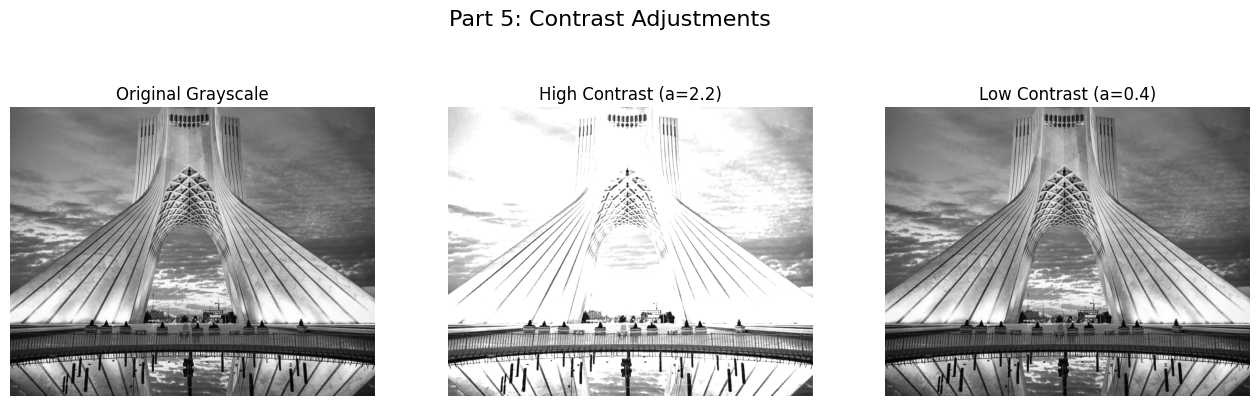


==================== PART 6 ====================


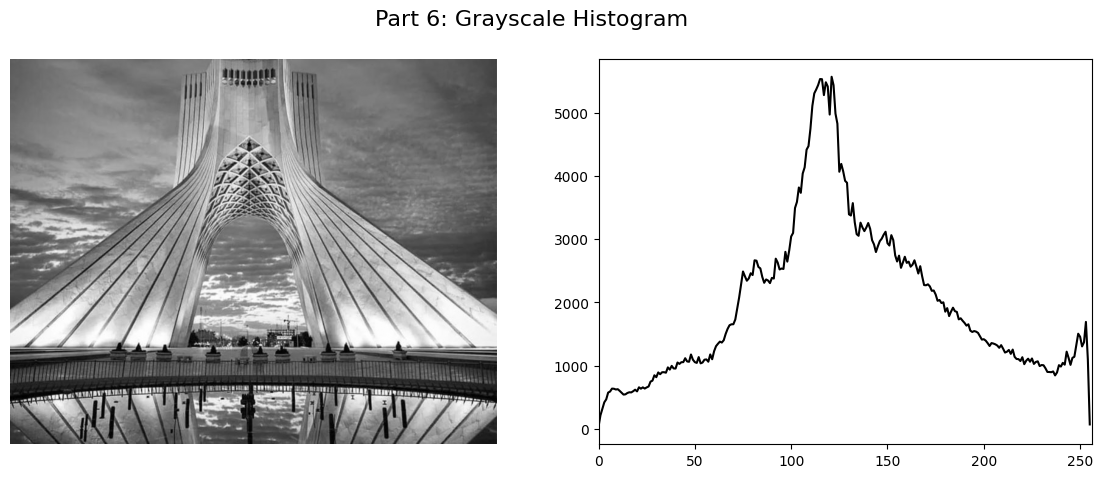

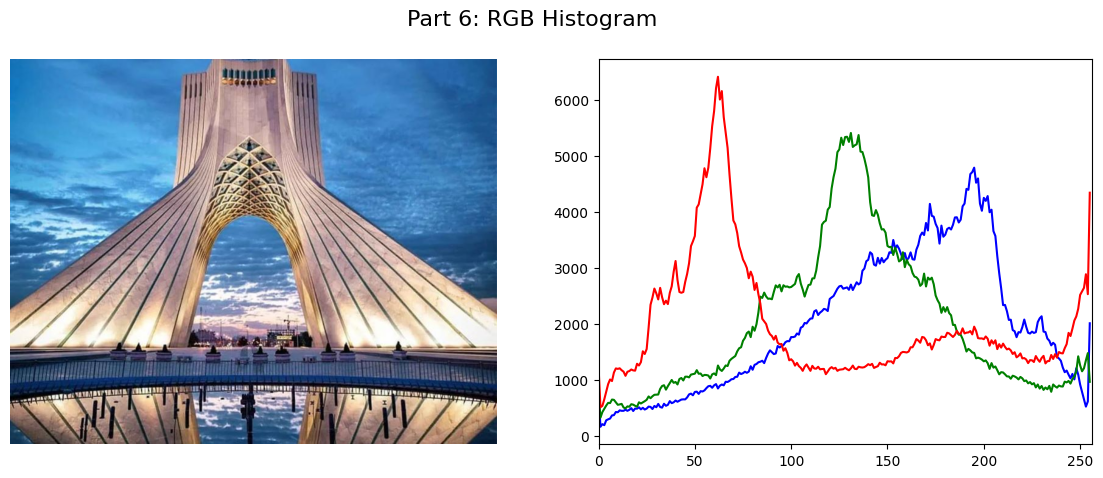


==================== PART 7 ====================
Stretched Contrast: 54.84
Equalized Contrast: 73.59


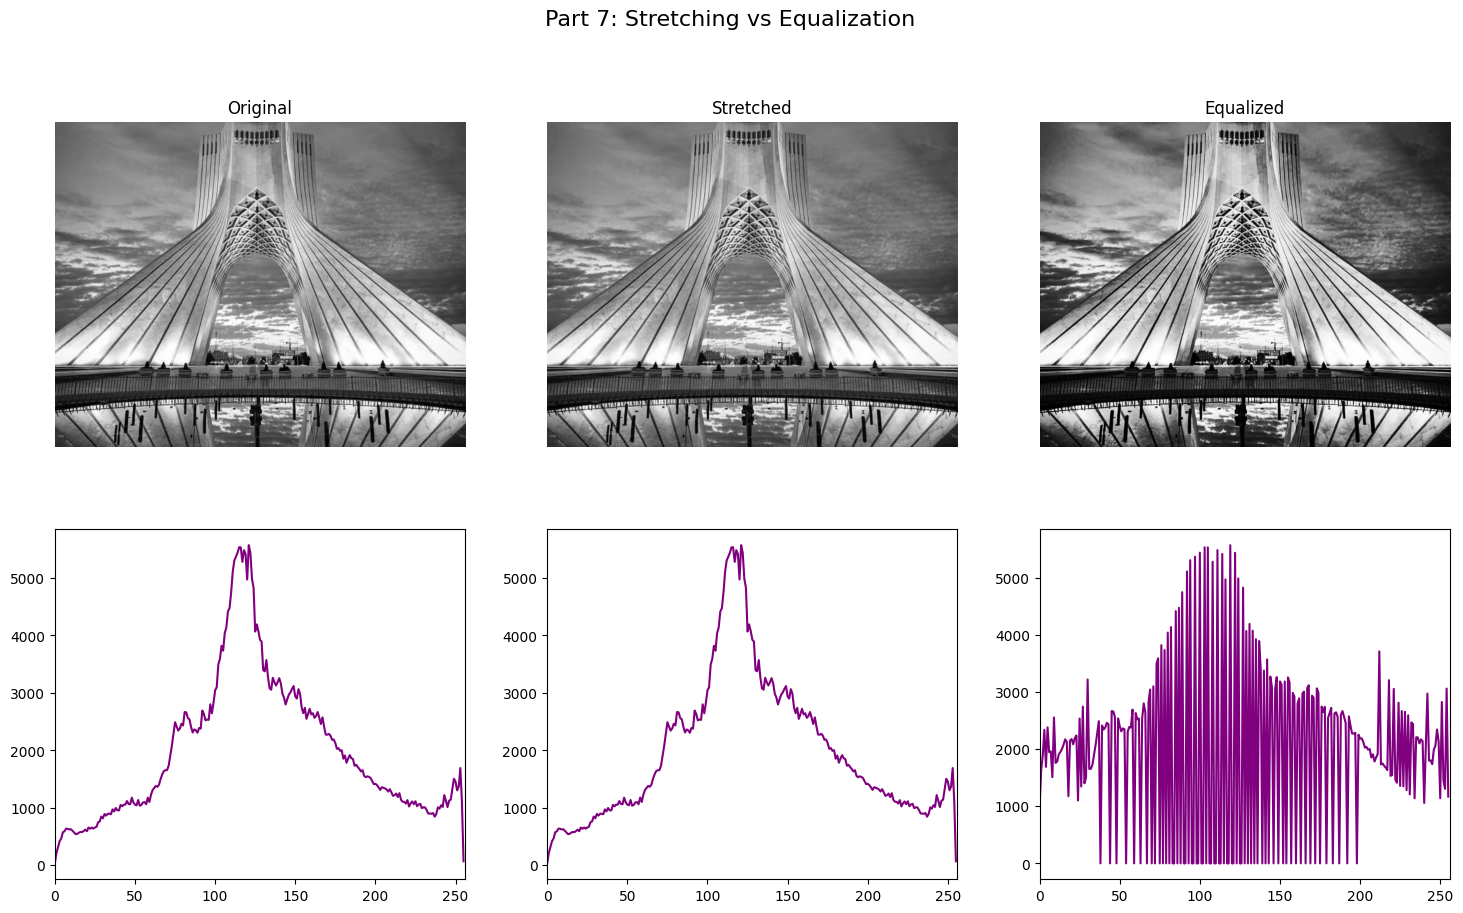

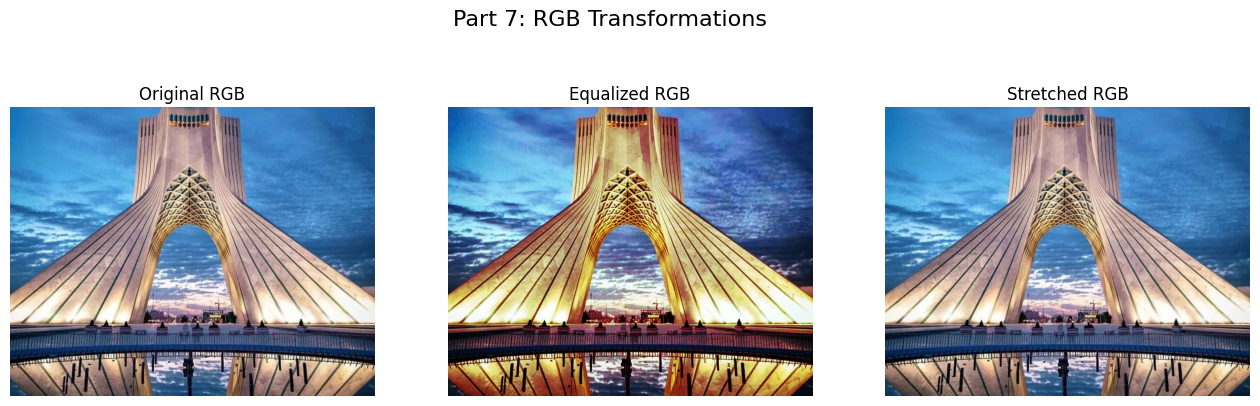

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*20 + " PART 1 " + "="*20)
img_path = 'Pic.jpg'
bgr_img = cv2.imread(img_path)

print(f"Dimensions: {bgr_img.shape}")
print(f"Data Type: {bgr_img.dtype}")
print(f"Channels: {bgr_img.shape[2]}")

print("\n" + "="*20 + " PART 2 " + "="*20)
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
_, bin_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

fig1, ax1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle('Part 2: Image Types', fontsize=16)
ax1[0].imshow(rgb_img)
ax1[0].set_title('RGB')
ax1[0].axis('off')
ax1[1].imshow(gray_img, cmap='gray')
ax1[1].set_title('Grayscale')
ax1[1].axis('off')
ax1[2].imshow(bin_img, cmap='gray')
ax1[2].set_title('Binary (Otsu)')
ax1[2].axis('off')
plt.show()

print("\n" + "="*20 + " PART 3 & 4 " + "="*20)
hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
r_ch, g_ch, b_ch = cv2.split(rgb_img)
h_ch, s_ch, v_ch = cv2.split(hsv_img)

fig2, ax2 = plt.subplots(2, 4, figsize=(18, 9))
fig2.suptitle('Part 3 & 4: Color Models and Channels', fontsize=16)

ax2[0, 0].imshow(rgb_img)
ax2[0, 0].set_title('RGB Image')
ax2[0, 0].axis('off')
ax2[0, 1].imshow(r_ch, cmap='gray')
ax2[0, 1].set_title('Red')
ax2[0, 1].axis('off')
ax2[0, 2].imshow(g_ch, cmap='gray')
ax2[0, 2].set_title('Green')
ax2[0, 2].axis('off')
ax2[0, 3].imshow(b_ch, cmap='gray')
ax2[0, 3].set_title('Blue')
ax2[0, 3].axis('off')

ax2[1, 0].imshow(cv2.cvtColor(hsv_img, cv2.COLOR_HSV2RGB))
ax2[1, 0].set_title('HSV Image')
ax2[1, 0].axis('off')
ax2[1, 1].imshow(h_ch, cmap='hsv')
ax2[1, 1].set_title('Hue')
ax2[1, 1].axis('off')
ax2[1, 2].imshow(s_ch, cmap='gray')
ax2[1, 2].set_title('Saturation')
ax2[1, 2].axis('off')
ax2[1, 3].imshow(v_ch, cmap='gray')
ax2[1, 3].set_title('Value')
ax2[1, 3].axis('off')
plt.tight_layout()
plt.show()

print("\n" + "="*20 + " PART 5 " + "="*20)
base_contrast = np.std(gray_img)
print(f"Base Contrast: {base_contrast:.2f}")

alpha_up = 2.2
alpha_down = 0.4
high_c_img = cv2.convertScaleAbs(gray_img, alpha=alpha_up, beta=0)
low_c_img = cv2.convertScaleAbs(gray_img, alpha=alpha_down, beta=0)

print(f"Contrast (Increased): {np.std(high_c_img):.2f}")
print(f"Contrast (Decreased): {np.std(low_c_img):.2f}")

fig3, ax3 = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle('Part 5: Contrast Adjustments', fontsize=16)
display_imgs = [gray_img, high_c_img, low_c_img]
display_titles = ['Original Grayscale', f'High Contrast (a={alpha_up})', f'Low Contrast (a={alpha_down})']

for i in range(3):
    ax3[i].imshow(display_imgs[i], cmap='gray')
    ax3[i].set_title(display_titles[i])
    ax3[i].axis('off')
plt.show()

print("\n" + "="*20 + " PART 6 " + "="*20)
gray_hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])

fig4, ax4 = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle('Part 6: Grayscale Histogram', fontsize=16)
ax4[0].imshow(gray_img, cmap='gray')
ax4[0].axis('off')
ax4[1].plot(gray_hist, color='black', linewidth=1.5)
ax4[1].set_xlim([0, 256])
plt.show()

fig5, ax5 = plt.subplots(1, 2, figsize=(14, 5))
fig5.suptitle('Part 6: RGB Histogram', fontsize=16)
ax5[0].imshow(rgb_img)
ax5[0].axis('off')

for ch, col in zip([b_ch, g_ch, r_ch], ['blue', 'green', 'red']):
    ch_hist = cv2.calcHist([ch], [0], None, [256], [0, 256])
    ax5[1].plot(ch_hist, color=col, linewidth=1.5)
ax5[1].set_xlim([0, 256])
plt.show()

print("\n" + "="*20 + " PART 7 " + "="*20)
eq_img = cv2.equalizeHist(gray_img)
g_min, g_max = np.min(gray_img), np.max(gray_img)
str_img = np.interp(gray_img, (g_min, g_max), (0, 255)).astype(np.uint8)

print(f"Stretched Contrast: {np.std(str_img):.2f}")
print(f"Equalized Contrast: {np.std(eq_img):.2f}")

fig6, ax6 = plt.subplots(2, 3, figsize=(18, 10))
fig6.suptitle('Part 7: Stretching vs Equalization', fontsize=16)

variations = [(gray_img, 'Original'), (str_img, 'Stretched'), (eq_img, 'Equalized')]
for idx, (im, name) in enumerate(variations):
    ax6[0, idx].imshow(im, cmap='gray')
    ax6[0, idx].set_title(name)
    ax6[0, idx].axis('off')
    
    h = cv2.calcHist([im], [0], None, [256], [0, 256])
    ax6[1, idx].plot(h, color='purple')
    ax6[1, idx].set_xlim([0, 256])
plt.show()

def transform_color_image(image, mode='equalize'):
    ch_list = cv2.split(image)
    processed_channels = []
    for c in ch_list:
        if mode == 'equalize':
            processed_channels.append(cv2.equalizeHist(c))
        else:
            c_min, c_max = np.min(c), np.max(c)
            processed_channels.append(np.interp(c, (c_min, c_max), (0, 255)).astype(np.uint8))
    return cv2.merge(processed_channels)

rgb_equalized = transform_color_image(bgr_img, 'equalize')
rgb_stretched = transform_color_image(bgr_img, 'stretch')

fig7, ax7 = plt.subplots(1, 3, figsize=(16, 5))
fig7.suptitle('Part 7: RGB Transformations', fontsize=16)
ax7[0].imshow(rgb_img)
ax7[0].set_title('Original RGB')
ax7[0].axis('off')
ax7[1].imshow(cv2.cvtColor(rgb_equalized, cv2.COLOR_BGR2RGB))
ax7[1].set_title('Equalized RGB')
ax7[1].axis('off')
ax7[2].imshow(cv2.cvtColor(rgb_stretched, cv2.COLOR_BGR2RGB))
ax7[2].set_title('Stretched RGB')
ax7[2].axis('off')
plt.show()

## report 1


### Part 2: Image Types Explanation

*   **RGB Image:** An additive color model where red, green, and blue light are added together in various ways to reproduce a broad array of colors. In standard digital images, it has 3 channels, with each channel typically using 8 bits (values from 0 to 255), as confirmed by output (`Data Type: uint8`, `Channels: 3`).
*   **Grayscale Image:** An image in which the value of each pixel is a single sample representing only an amount of light (intensity or luminance). It carries no color information and consists of varying shades of gray, from black (0) at the weakest intensity to white (255) at the strongest. 
*   **Binary Image:** An image that consists of only two possible pixel values, typically 0 (black) and 255 (white). It is usually created by applying a threshold to a grayscale image (like the Otsu method you used), which is highly useful for separating foreground objects from the background.

### Part 3: HSV Color Model

*   **HSV (Hue, Saturation, Value):** This model represents color in a way that is much closer to how human vision actually perceives color-making attributes. 
    *   **Hue:** Represents the color type (e.g., red, blue, yellow) and is often modeled as an angle from 0 to 360 degrees.
    *   **Saturation:** Represents the vividness or purity of the color. Lower saturation makes the color look more washed out or gray, while higher saturation is more intense.
    *   **Value:** Represents the brightness of the color, ranging from completely black to fully bright.

### Part 5: Contrast Definition & Analysis

*   **Definition:** Contrast is the difference in luminance or color that makes an object distinguishable from other objects and the background. In digital image processing, a common metric to calculate contrast is the Root Mean Square (RMS) contrast, which is essentially the standard deviation of the pixel intensities: 
    $$C = \sqrt{\frac{1}{MN}\sum_{i=0}^{M-1}\sum_{j=0}^{N-1}(I(i,j) - \bar{I})^2}$$
    where $\bar{I}$ is the average image intensity. 
*   **Analysis of Output:**
    *   **Base Contrast:** `54.84`
    *   **Increased Contrast:** `56.74` (The intensity values were spread further apart by multiplying with an alpha value $>1$).
    *   **Decreased Contrast:** `21.94` (The intensity values were compressed together by multiplying with an alpha value $<1$, making the image look flatter and grayer).

### Part 6: Histogram Definition

*   **Definition:** An image histogram is a graphical representation of the tonal distribution in a digital image. It plots the number of pixels for each specific intensity value (from 0 to 255 for an 8-bit image). Analyzing a histogram allows us to understand the exposure, contrast, and dynamic range of the image at a glance.

### Part 7: Histogram Stretching vs. Histogram Equalization

*   **Histogram Stretching (Linear Contrast Stretching):**
    *   **Definition:** A linear transformation technique that stretches the original range of intensity values to span the full possible dynamic range (e.g., 0 to 255). It maps the minimum existing intensity to 0 and the maximum to 255. 
    *   * Result (`54.84`):** The contrast remained exactly the same as the base contrast. This happens when the original image already has pixels that span the entire 0 to 255 range (or very close to it). In such cases, linear stretching mathematically maps the pixels back to almost their exact original values.
*   **Histogram Equalization:**
    *   **Definition:** A non-linear process that redistributes the pixel intensities so that the cumulative probability function approaches a linear curve. Instead of just stretching the boundaries, it effectively flattens the histogram, spreading out the most frequent intensity values. This enhances the global contrast of images, especially when the usable data is represented by close contrast values.
    *   * Result (`73.59`):** As expected, equalization significantly increased the standard deviation of pixel intensities compared to the base contrast, pulling hidden details out of low-contrast areas.

## 2


==================== PART 1 & 2 ====================


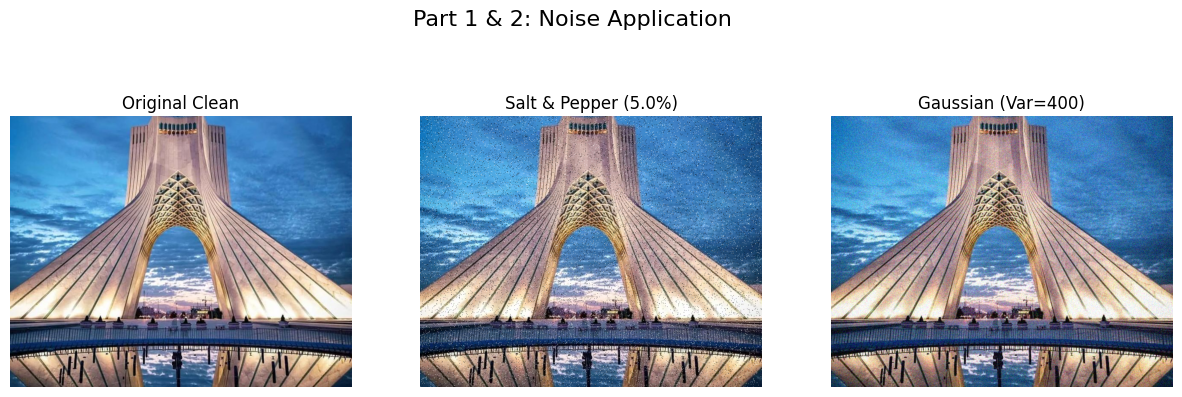


==================== PART 4 ====================
Custom kernel function defined successfully.

==================== PART 5 & 6 ====================


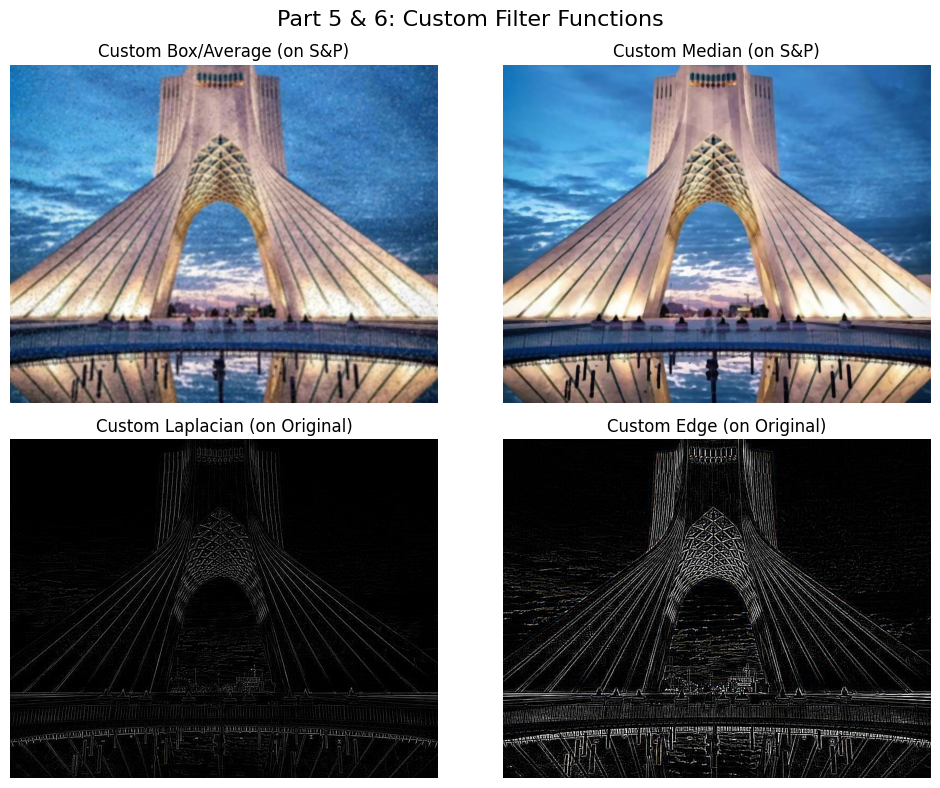


==================== PART 7 ====================


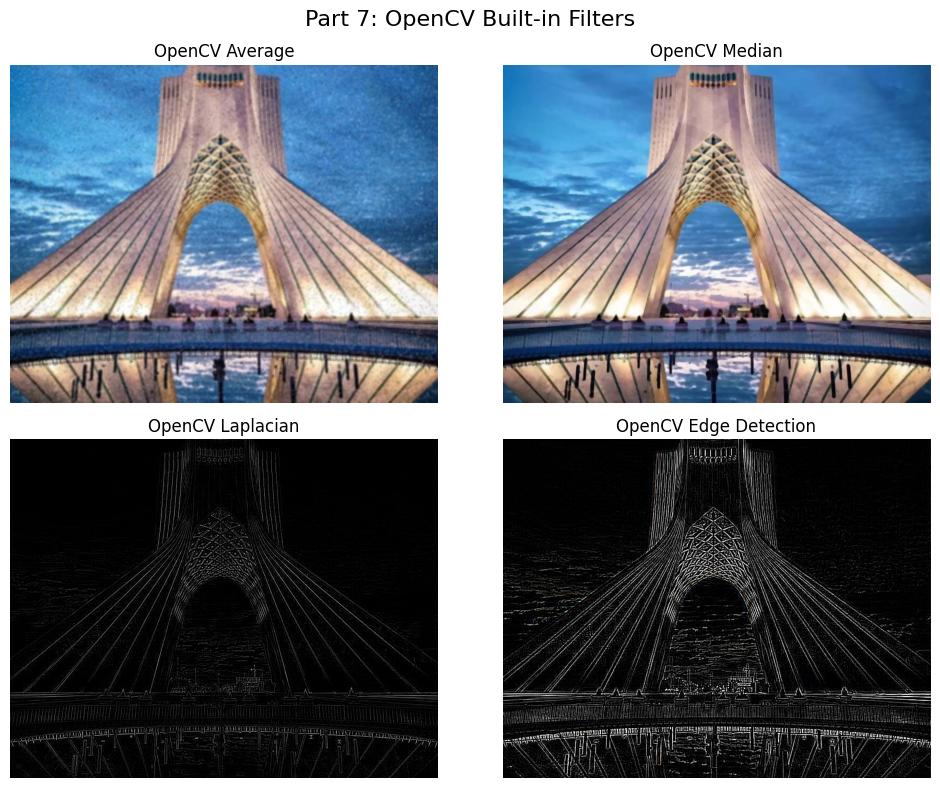

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*20 + " PART 1 & 2 " + "="*20)
source_img = cv2.imread('Pic.jpg')
rgb_source = cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB)

def generate_sp_noise(image, ratio):
    noisy_img = np.copy(image)
    h, w = noisy_img.shape[:2]
    total_pixels = h * w
    
    salt_count = int(total_pixels * ratio / 2)
    pepper_count = int(total_pixels * ratio / 2)
    
    salt_y = np.random.randint(0, h, salt_count)
    salt_x = np.random.randint(0, w, salt_count)
    noisy_img[salt_y, salt_x] = [255, 255, 255]
    
    pepper_y = np.random.randint(0, h, pepper_count)
    pepper_x = np.random.randint(0, w, pepper_count)
    noisy_img[pepper_y, pepper_x] = [0, 0, 0]
    
    return noisy_img

sp_rate = 0.05
img_sp = generate_sp_noise(rgb_source, sp_rate)

g_mean = 0
g_var = 400
g_sigma = np.sqrt(g_var)
gaussian_matrix = np.random.normal(g_mean, g_sigma, rgb_source.shape)
img_gaussian = np.clip(rgb_source + gaussian_matrix, 0, 255).astype(np.uint8)

fig1, ax1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle('Part 1 & 2: Noise Application', fontsize=16)
ax1[0].imshow(rgb_source)
ax1[0].set_title('Original Clean')
ax1[0].axis('off')
ax1[1].imshow(img_sp)
ax1[1].set_title(f'Salt & Pepper ({sp_rate*100}%)')
ax1[1].axis('off')
ax1[2].imshow(img_gaussian)
ax1[2].set_title(f'Gaussian (Var={g_var})')
ax1[2].axis('off')
plt.show()

print("\n" + "="*20 + " PART 4 " + "="*20)
def apply_custom_kernel(img, kernel_data, filter_type='linear'):
    h, w, c = img.shape
    
    if filter_type == 'linear':
        kh, kw = kernel_data.shape
    else:
        kh, kw = kernel_data, kernel_data
        
    ph, pw = kh // 2, kw // 2
    padded_img = np.pad(img, ((ph, ph), (pw, pw), (0, 0)), mode='edge')
    result = np.zeros_like(img, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+kh, j:j+kw, :]
            if filter_type == 'linear':
                for k in range(c):
                    result[i, j, k] = np.sum(region[:, :, k] * kernel_data)
            elif filter_type == 'median':
                for k in range(c):
                    result[i, j, k] = np.median(region[:, :, k])

    return np.clip(result, 0, 255).astype(np.uint8)
print("Custom kernel function defined successfully.")

print("\n" + "="*20 + " PART 5 & 6 " + "="*20)
box_kernel = np.ones((5, 5), dtype=np.float32) / 25.0
custom_blur = apply_custom_kernel(img_sp, box_kernel, 'linear')

custom_med = apply_custom_kernel(img_sp, 5, 'median')

laplace_k = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
custom_laplace = apply_custom_kernel(rgb_source, laplace_k, 'linear')

edge_k = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)
custom_edge = apply_custom_kernel(rgb_source, edge_k, 'linear')

fig2, ax2 = plt.subplots(2, 2, figsize=(10, 8))
fig2.suptitle('Part 5 & 6: Custom Filter Functions', fontsize=16)
ax2[0, 0].imshow(custom_blur)
ax2[0, 0].set_title('Custom Box/Average (on S&P)')
ax2[0, 0].axis('off')
ax2[0, 1].imshow(custom_med)
ax2[0, 1].set_title('Custom Median (on S&P)')
ax2[0, 1].axis('off')
ax2[1, 0].imshow(custom_laplace)
ax2[1, 0].set_title('Custom Laplacian (on Original)')
ax2[1, 0].axis('off')
ax2[1, 1].imshow(custom_edge)
ax2[1, 1].set_title('Custom Edge (on Original)')
ax2[1, 1].axis('off')
plt.tight_layout()
plt.show()

print("\n" + "="*20 + " PART 7 " + "="*20)
cv_blur = cv2.filter2D(img_sp, -1, box_kernel)
cv_med = cv2.medianBlur(img_sp, 5)
cv_laplace = cv2.filter2D(rgb_source, -1, laplace_k)
cv_edge = cv2.filter2D(rgb_source, -1, edge_k)

fig3, ax3 = plt.subplots(2, 2, figsize=(10, 8))
fig3.suptitle('Part 7: OpenCV Built-in Filters', fontsize=16)
ax3[0, 0].imshow(cv_blur)
ax3[0, 0].set_title('OpenCV Average')
ax3[0, 0].axis('off')
ax3[0, 1].imshow(cv_med)
ax3[0, 1].set_title('OpenCV Median')
ax3[0, 1].axis('off')
ax3[1, 0].imshow(cv_laplace)
ax3[1, 0].set_title('OpenCV Laplacian')
ax3[1, 0].axis('off')
ax3[1, 1].imshow(cv_edge)
ax3[1, 1].set_title('OpenCV Edge Detection')
ax3[1, 1].axis('off')
plt.tight_layout()
plt.show()

## report

Here is the theoretical report and analysis for the second part of your assignment, formatted in English Markdown based on the outputs we generated. You can copy and paste this directly into your Jupyter Notebook or report.

***

### Part 1 & 2: Image Properties and Noise Application

**1. Image Properties:**
*   **Dimensions:** `(633, 800, 3)` indicating a height of 633 pixels, a width of 800 pixels, and 3 color channels.
*   **Data Type:** `uint8` (8-bit unsigned integer), meaning each pixel's intensity is represented by a value between 0 and 255.
*   **Channels:** `3`, confirming it is a standard color image (RGB/BGR).

**2. Noise Analysis:**
*   **Salt and Pepper Noise (5%):** This is impulse noise that randomly alters a certain percentage of pixels (here, 5%) to either their maximum value (white/salt, 255) or minimum value (black/pepper, 0). It creates distinct, isolated dots across the image.
*   **Gaussian Noise (Variance = 400):** This is statistical noise characterized by a probability density function equal to the normal (Gaussian) distribution. Unlike salt and pepper noise, Gaussian noise affects almost every pixel in the image by adding a random, normally distributed value, simulating electronic sensor or low-light noise. It results in a globally grainy or fuzzy appearance.

### Part 4: The Concept of a Kernel

**What is a Kernel?**
In image processing, a kernel (or mask/matrix) is a small 2D array of numbers used to apply effects like blurring, sharpening, or edge detection. 
*   **How it is applied (Convolution):** The kernel slides over the image pixel by pixel. At each position, the overlapping image pixels are multiplied by the corresponding kernel values, and the results are summed up. This sum becomes the new value for the center pixel in the output image.


### Part 5: Low-Pass Filters (Noise Reduction)

We applied two low-pass filters to the image corrupted with Salt and Pepper noise:

1.  **Convolutional Low-pass (Average/Box Filter 5x5):** 
    This filter calculates the mean of all pixels within the 5x5 window. When applied to Salt and Pepper noise, it averages the extreme values (0 and 255) with the surrounding pixels. As a result, it blurs the image and smears the noise into gray spots, but **fails to remove the noise effectively**.
2.  **Non-Convolutional Low-pass (Median Filter 5x5):**
    Instead of math operations, this filter sorts the pixel values in the window and picks the middle (median) value. Since Salt and Pepper noise consists of extreme outliers (0 or 255), they are pushed to the ends of the sorted list and are never selected as the median. 
    *   **Conclusion:** The **Median filter is vastly superior** for removing Salt and Pepper noise, as it eliminates the impulse dots entirely while preserving the edges of the image much better than the average filter.

### Part 6: High-Pass Filters (Edge Detection)

We applied two high-pass filters to the original, clean image:

1.  **Laplacian Filter:** 
    This is a 2nd-order derivative filter used to find areas of rapid change in pixel intensity (edges). It highlights fine details but is omnidirectional (finds edges in all directions equally). Because it calculates derivatives, it is highly sensitive to noise.
2.  **Custom Edge Detection Kernel:** 
    A specific matrix (often a modified high-boost filter, e.g., center value 8, surrounded by -1s) designed to highlight boundaries between different regions of the image. The output typically results in a dark background with bright, prominent outlines indicating structural edges.

### Part 7: Comparison with Built-in OpenCV Functions

After applying the same filters using OpenCV's highly optimized built-in functions (`cv2.filter2D` for convolution and `cv2.medianBlur` for the median filter), the visual results were compared:

*   **Result:** The visual outputs from the custom Python functions are identical to the outputs from OpenCV. 
*   **Difference:** The primary difference lies in **execution speed and computational efficiency**. The custom nested `for` loops in Python are computationally expensive and slow. Conversely, OpenCV functions are written in highly optimized C/C++ and utilize vectorization, making them exponentially faster for real-time image processing.

# 3

In [10]:
import cv2
import numpy as np

print("\n" + "="*20 + " PART 3: Q1 & Q2 " + "="*20)
source_vid = 'Original_Vid.mp4'
vid_cap = cv2.VideoCapture(source_vid)

if not vid_cap.isOpened():
    print("Error: Could not open video file.")
else:
    vid_frames = int(vid_cap.get(cv2.CAP_PROP_FRAME_COUNT))
    vid_fps = vid_cap.get(cv2.CAP_PROP_FPS)
    vid_w = int(vid_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vid_h = int(vid_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Video File: {source_vid}")
    print(f"Total Frames: {vid_frames}")
    print(f"FPS: {vid_fps:.2f}")

    print("\n" + "="*20 + " PART 3: Q3 & Q4 " + "="*20)
    
    def fast_sp_noise(frame_in, noise_level=0.05):
        frame_out = np.copy(frame_in)
        rand_matrix = np.random.rand(frame_out.shape[0], frame_out.shape[1])
        frame_out[rand_matrix < (noise_level / 2)] = 255
        frame_out[rand_matrix > 1 - (noise_level / 2)] = 0
        return frame_out

    noisy_out_name = "Vid_Noisy.mp4"
    filtered_out_name = "Vid_Filtered.mp4"
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    noisy_writer = cv2.VideoWriter(noisy_out_name, fourcc, vid_fps, (vid_w, vid_h))
    filtered_writer = cv2.VideoWriter(filtered_out_name, fourcc, vid_fps, (vid_w, vid_h))

    print("Processing video frames (Adding Noise & Filtering)... Please wait.")

    while True:
        ret, frame = vid_cap.read()
        if not ret:
            break
            
        noisy_frame = fast_sp_noise(frame, 0.05)
        noisy_writer.write(noisy_frame)
        
        filtered_frame = cv2.medianBlur(noisy_frame, 5)
        filtered_writer.write(filtered_frame)

    vid_cap.release()
    noisy_writer.release()
    filtered_writer.release()

    print(f"Processing complete.")
    print(f"Noisy video saved as: {noisy_out_name}")
    print(f"Filtered video saved as: {filtered_out_name}")


==================== PART 3: Q1 & Q2 ====================
Video File: Original_Vid.mp4
Total Frames: 309
FPS: 29.97

==================== PART 3: Q3 & Q4 ====================
Processing video frames (Adding Noise & Filtering)... Please wait.
Processing complete.
Noisy video saved as: Vid_Noisy.mp4
Filtered video saved as: Vid_Filtered.mp4


## report


### Part 3: Video Processing

**1 & 2. Video Loading and Properties:**
The target video `Original_Vid.mp4` was successfully loaded using OpenCV's `VideoCapture` class. By extracting the video properties using `cv2.CAP_PROP_FRAME_COUNT` and `cv2.CAP_PROP_FPS`, the following specifications were obtained:
*   **Total Number of Frames:** 309
*   **Frames Per Second (FPS):** 29.97

**3. Applying Salt and Pepper Noise:**
A 5% Salt and Pepper noise was introduced to every single frame of the video. To optimize execution time for video processing, a vectorized probability matrix was used instead of traditional nested loops. The resulting corrupted frames were compiled and exported as `Vid_Noisy.mp4` using the `mp4v` codec.

**4. Filtering the Noisy Video:**
To restore the noisy video, a **Median Filter** (`cv2.medianBlur` with a 5x5 kernel) was applied to the corrupted frames. 
*   **Kernel Justification:** As concluded in Part 2 of this assignment, standard linear filters (like the Box/Average filter) simply blur impulse noise into the image. The Median filter is non-linear and perfectly suited for Salt and Pepper noise; it effectively replaces the extreme noise pixel values (0 and 255) with the median value of their neighboring pixels, successfully restoring the video while maintaining the sharpness of structural edges.
The cleaned frames were then exported as the final output file `Vid_Filtered.mp4`.